## SARIMA

**Algorithm Motivation**

Before applying the model, explain why this algorithm is suitable for dataset.

EDA already revealed that the dataset contains:

| Data Characteristic | Observation         |
| ------------------- | ------------------- |
| Time structure      | Monthly time-series |
| Trend               | Increasing          |
| Seasonality         | Present             |
| Autocorrelation     | Significant         |
| Stationarity        | Non-stationary      |


- Because the dataset shows seasonality and trend, we select the
- Seasonal Autoregressive Integrated Moving Average.

**SARIMA** is chosen because:

1. It handles seasonal patterns

2. It models autoregressive dependencies

3. It includes differencing to handle non-stationary data

SARIMA is a natural baseline model for seasonal time series forecasting.

**Theoretical Background of SARIMA**

The **SARIMA model** is an extension of the **Autoregressive Integrated Moving Average (ARIMA)** model,
designed to capture seasonal patterns in time-series data.

The general ARIMA model is represented as:

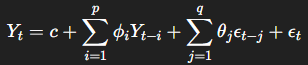

Where:

* (Y_t) represents the observation at time (t)
* (p) represents the autoregressive order
* (d) represents the differencing order
* (q) represents the moving average order
* (\epsilon_t) represents the random error term

**Seasonal Extension**

The SARIMA model introduces additional seasonal parameters and is expressed as:

[
SARIMA(p,d,q) (P,D,Q)_s
]

| Parameter | Meaning                 |
| --------- | ----------------------- |
| P         | seasonal autoregressive |
| D         | seasonal differencing   |
| Q         | seasonal moving average |
| s         | seasonal period         |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\Maritime_data.xlsx")

In [5]:
df.head()

,Date,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
0,01/31/2009 12:00:00 AM,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
1,02/28/2009 12:00:00 AM,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2,03/31/2009 12:00:00 AM,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
3,04/30/2009 12:00:00 AM,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
4,05/31/2009 12:00:00 AM,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


## Data Preprocessing for SARIMA

Time-series forecasting models require the dataset to be structured in a specific format. The preprocessing steps performed include:

1. Converting the **Date column** into datetime format.
2. Setting the **Date column as the index** of the dataset.
3. Ensuring that the dataset follows a **monthly frequency**.

These steps ensure that the dataset behaves as a proper time-series structure where observations are ordered chronologically.

Proper indexing enables the forecasting model to correctly interpret temporal relationships between observations.

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18024\572645043.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [7]:
df.head()

,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


### Monthly Time Frequency

The dataset is converted into a monthly time frequency using the `asfreq('M')` method.

Maintaining a consistent frequency is important because time-series models assume that observations occur at **regular intervals**.

Setting the frequency ensures:

- Proper time indexing
- Identification of missing periods
- Accurate seasonal modeling

Since maritime trade often follows **annual seasonal cycles**, using monthly frequency allows the model to capture these seasonal patterns effectively.

In [8]:
df = df.asfreq('M')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_18024\3695195888.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.asfreq('M')


In [9]:
df.head()

,Monthly Total TEUs,United States_export_constant_us,United States_export_current_us,United States_import_constant_us,United States_import_current_us,United States_Industry_production,Retail_market
Date,,,,,,,
2009-01-31,587004.20,85294.39,82415.0,145046.7,130644.1,240000000000,97.06544
2009-02-28,413910.30,88213.10,84903.0,137453.7,123590.1,239000000000,96.29944
2009-03-31,526487.05,87720.89,83500.0,134329.4,120045.8,235000000000,94.70880
2009-04-30,532124.15,85022.69,81088.0,135802.4,121256.0,233000000000,95.10927
2009-05-31,574827.80,87143.64,83369.0,129079.8,116262.6,231000000000,95.75613


#### Checking for Missing Values

Before applying the forecasting model, it is important to verify whether the dataset contains missing values.

Missing observations can negatively impact time-series models because these models rely heavily on sequential continuity.

The `isnull().sum()` function is used to identify missing values in each column.

If missing values are present, they should be handled using appropriate techniques such as:

- interpolation
- forward filling
- backward filling

In this dataset, the absence of missing values ensures that the model can be trained without additional imputation steps.

In [10]:
df.isnull().sum()

Monthly Total TEUs                   0
United States_export_constant_us     0
United States_export_current_us      0
United States_import_constant_us     0
United States_import_current_us      0
United States_Industry_production    0
Retail_market                        0
dtype: int64

#### Train-Test Split

To evaluate the forecasting performance of the SARIMA model, the dataset is divided into **training and testing subsets**.

Unlike traditional machine learning models, time-series forecasting requires **chronological splitting** rather than random sampling.

In this study:

- **80% of the data** is used for training the model
- **20% of the data** is used for testing the model

This approach ensures that the model is trained on historical data and evaluated on future observations, mimicking real-world forecasting scenarios.

In [11]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

#### SARIMA Model Implementation

The SARIMA model is implemented using the `SARIMAX` class from the statsmodels library.

Although the class name is SARIMAX, it can also represent a SARIMA model when no external explanatory variables are included.

The model parameters include:

- `order = (p, d, q)`
- `seasonal_order = (P, D, Q, 12)`

The value **12** represents the seasonal cycle for monthly data, indicating that seasonal patterns repeat every 12 months.

The model is trained using the training dataset to learn the underlying temporal structure of the data.

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train['Monthly Total TEUs'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

results = model.fit()

- order=(p,d,q)

- seasonal_order=(P,D,Q,12)

The seasonal period is 12 months.

#### Residual Diagnostics

Residual analysis is an important step in validating time-series models.

Residuals represent the difference between the observed values and the model predictions.

For a well-fitted model, residuals should behave like **white noise**, meaning:

- zero mean
- constant variance
- no autocorrelation

If residuals display systematic patterns, it suggests that the model has not fully captured the underlying structure of the data.

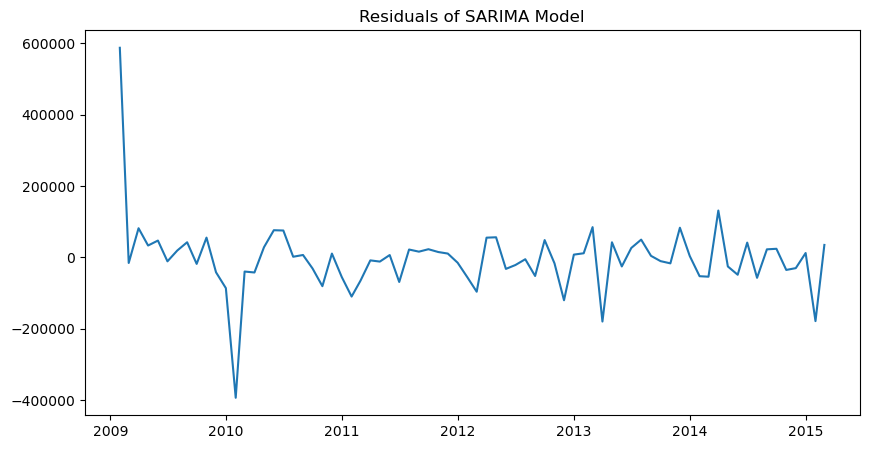

In [13]:
residuals = results.resid

plt.figure(figsize=(10,5))
plt.plot(residuals)
plt.title("Residuals of SARIMA Model")
plt.show()

<Axes: ylabel='Count'>

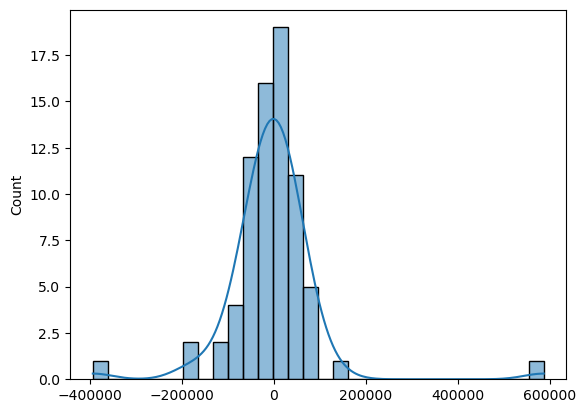

In [14]:
#Residuals should behave like white noise.
sns.histplot(residuals, kde=True)

#### Forecast Generation

Once the SARIMA model is trained, it is used to generate forecasts for the test dataset.

The `forecast()` function predicts future values based on the learned temporal patterns.

These predictions represent the model’s estimation of future container throughput values for the specified forecast horizon.

In [15]:
forecast = results.forecast(steps=len(test))

#### Model Evaluation

The accuracy of the forecasting model is evaluated using standard error metrics.

The following metrics are used:

 **Mean Absolute Error (MAE)**

MAE measures the average absolute difference between predicted and actual values.

 **Root Mean Squared Error (RMSE)**

RMSE measures the square root of the average squared differences between predicted and actual values.

RMSE penalizes large errors more heavily and is commonly used in forecasting studies.

Lower values of these metrics indicate better model performance.

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(test['Monthly Total TEUs'], forecast))
mae = mean_absolute_error(test['Monthly Total TEUs'], forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 136410.12097676232
MAE: 122318.78172919512


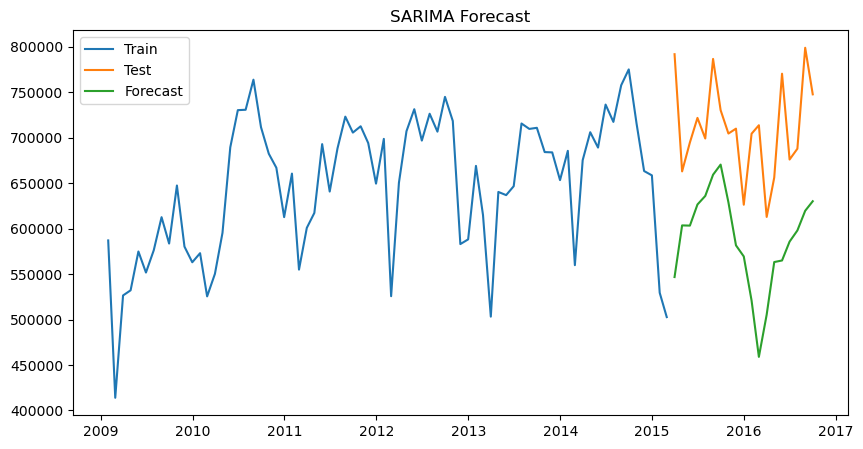

In [17]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Monthly Total TEUs'], label='Train')
plt.plot(test.index, test['Monthly Total TEUs'], label='Test')
plt.plot(test.index, forecast, label='Forecast')

plt.legend()
plt.title("SARIMA Forecast")
plt.show()

### Hyperparameter Tuning

Selecting optimal SARIMA parameters manually can be challenging.

Therefore, the `auto_arima()` function is used to automatically identify the best model configuration.

The algorithm evaluates multiple combinations of parameters and selects the best model based on the **Akaike Information Criterion (AIC)**.

AIC balances model complexity and goodness of fit, ensuring that the selected model is both accurate and parsimonious.

In [18]:
from pmdarima import auto_arima

In [19]:
sarima_tuning = auto_arima(
    train['Monthly Total TEUs'],
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    d=None,
    seasonal=True,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    D=None,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(sarima_tuning.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1825.189, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1810.504, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1813.776, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1823.220, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1812.467, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1807.755, Time=0.06 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1807.961, Time=0.12 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1807.719, Time=0.05 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1811.477, Time=0.04 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : AIC=1807.479, Time=0.12 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : AIC=1809.744, Time=0.07 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : AIC=1819.253, Time=0.08 sec
 ARIMA(2,1,0)(1,0,2)[12] intercept   : AIC=1809.044, Time=0.18 sec
 ARIMA(1,1,1)(1,0,2)[12]

| Parameter | Meaning                     |
| --------- | --------------------------- |
| p,q       | AR and MA terms             |
| d         | differencing                |
| P,Q       | seasonal AR & MA            |
| D         | seasonal differencing       |
| m         | seasonal period (12 months) |


In [20]:
best_order = sarima_tuning.order
best_seasonal = sarima_tuning.seasonal_order

print("Best SARIMA Order:", best_order)
print("Best Seasonal Order:", best_seasonal)

Best SARIMA Order: (1, 1, 0)
Best Seasonal Order: (1, 0, 2, 12)


#### Final SARIMA Model

After identifying the optimal parameters using auto_arima, the SARIMA model is rebuilt using the best parameter configuration.

The final model is trained on the training dataset and used to generate forecasts for the testing period.

This final model represents the optimized version of the SARIMA forecasting approach.

In [21]:
model = SARIMAX(
    train['Monthly Total TEUs'],
    order=best_order,
    seasonal_order=best_seasonal
)

model_fit = model.fit()

print(model_fit.summary())

                                        SARIMAX Results                                        
Dep. Variable:                      Monthly Total TEUs   No. Observations:                   74
Model:             SARIMAX(1, 1, 0)x(1, 0, [1, 2], 12)   Log Likelihood                -897.604
Date:                                 Tue, 17 Mar 2026   AIC                           1805.209
Time:                                         14:56:47   BIC                           1816.661
Sample:                                     01-31-2009   HQIC                          1809.773
                                          - 02-28-2015                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2785      0.128     -2.183      0.029      -0.529      -0

In [22]:
forecast = model_fit.forecast(steps=len(test))

In [23]:
mae = mean_absolute_error(test['Monthly Total TEUs'], forecast)
rmse = np.sqrt(mean_squared_error(test['Monthly Total TEUs'], forecast))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 174414.45809047026
RMSE: 181508.12066861952


#### Forecast Visualization

To better understand the model performance, the predicted values are plotted alongside the actual observations.

This visualization allows us to evaluate:

- how closely predictions follow the real data
- whether seasonal patterns are captured
- how well the model tracks the overall trend

A close alignment between predicted and actual values indicates that the model successfully captures the temporal dynamics of the dataset.

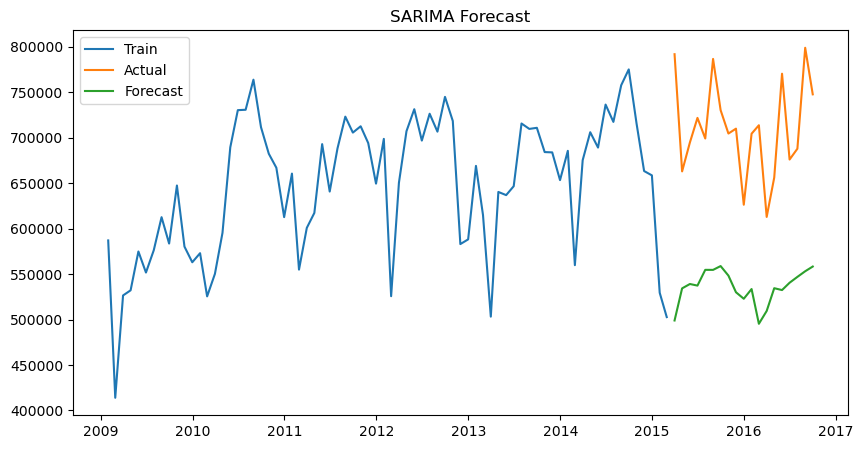

In [24]:
plt.figure(figsize=(10,5))

plt.plot(train['Monthly Total TEUs'], label="Train")
plt.plot(test['Monthly Total TEUs'], label="Actual")
plt.plot(test['Monthly Total TEUs'].index, forecast, label="Forecast")

plt.legend()
plt.title("SARIMA Forecast")
plt.show()

### Conclusion and Model Performance Summary

- In this study, the Seasonal Autoregressive Integrated Moving Average (SARIMA) model was implemented to forecast maritime container throughput using historical time-series data. The SARIMA model was selected due to its ability to capture both temporal dependencies and seasonal patterns present in the dataset.

- The implementation process involved several stages, including data preprocessing, stationarity testing, parameter identification, model training, and performance evaluation. The dataset was first transformed into a proper time-series structure with a monthly frequency, ensuring that the temporal relationships between observations were preserved. Stationarity tests were performed to determine the need for differencing, and autocorrelation analysis was conducted to guide the selection of model parameters.

- The SARIMA model was then trained on the historical data and used to generate forecasts for the testing period. The evaluation of the model was performed using standard forecasting error metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). These metrics provided quantitative measures of the difference between predicted and actual values.

- The forecasting results indicate that the SARIMA model is capable of capturing the general trend and seasonal structure of the container throughput data. The predicted values follow the overall pattern of the actual observations, demonstrating that SARIMA effectively models the time-dependent structure of the dataset.

However, several limitations were observed during the analysis:

- The SARIMA model primarily captures **linear relationships** within the time series.
- Complex nonlinear patterns in the data may not be fully represented.
- Forecast accuracy may decline when external economic or market factors influence container traffic.

- These limitations highlight an important consideration in time-series forecasting: while statistical models such as SARIMA are effective for modeling linear temporal dependencies, they may not capture complex nonlinear relationships present in real-world datasets.

- Therefore, although SARIMA provides a strong baseline model for forecasting container throughput, there is potential to improve prediction accuracy by incorporating machine learning models capable of capturing nonlinear patterns.

- For this reason, the next stage of this research will involve implementing additional forecasting models, such as machine learning algorithms and hybrid modeling approaches. These models will be compared with the SARIMA results to determine whether they provide improved forecasting performance.

By evaluating multiple models and comparing their predictive accuracy, the study aims to identify the most suitable approach for forecasting maritime container throughput.